# End-to-End Data Science Project: Titanic Survival Prediction

**Project Goal:** This notebook shows step by step how a data science project is approached from scratch, and how a robust, production-ready model is developed.

**Scenario:** Using the Titanic shipwreck data, we will build a machine learning model that predicts whether a passenger survived.

**Project Steps:**

1.  **Problem Definition:** Understanding the business goal.
2.  **Data Collection and Loading:** Installing the required libraries and loading the data.
3.  **Exploratory Data Analysis (EDA):** Understanding the data, visualizing it, and extracting insights.
4.  **Feature Engineering:** Deriving new, meaningful features from the existing data.
5.  **Data Preparation (Preprocessing):** Getting the data into a format the models can understand (Train/Test split).
6.  **Building the Pipeline:** Automating the data processing flow with `ColumnTransformer` and `Pipeline`.
7.  **Model Selection and Baseline:** Quickly testing different models.
8.  **Hyperparameter Optimization:** Optimizing the best model with `GridSearchCV`.
9.  **Final Model Evaluation:** Evaluating the model on the test data (Confusion Matrix, Reporting).
10. **Saving the Model and New Predictions:** Saving the trained pipeline and making predictions on new data.

-----

### Step 1: Problem Definition

  * **Business Problem:** Understanding which passengers survived the Titanic disaster, which features (age, sex, ticket class, etc.) influenced this, and predicting the survival probability of a passenger for a similar future scenario (or for this dataset).
  * **Target Variable:** `Survived` (0 = No, 1 = Yes)
  * **Problem Type:** This is a **Binary Classification** problem.
  * **Success Metric:** `Accuracy` is a general success measure. However, `Precision`, `Recall`, and `F1-Score` are also important for imbalanced classes. We will focus on `Accuracy` and `F1-Score`.


### Step 2: Data Collection and Loading

We import all the required libraries and load our data.

In [1]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer # SimpleImputer fills missing values with the median.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
%matplotlib inline
sns.set(style="whitegrid")


In [2]:
# Loading the dataset
# From a local file or a URL, just like in the original notebook
try:
    # Assume the file data/titanic.csv exists
    titanic_df = pd.read_csv('data/titanic.csv')
except FileNotFoundError:
    # If the file doesn't exist, fetch it from the internet
    print("Local file not found. Fetching data from the internet...")
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    titanic_df = pd.read_csv(url)

print("Data loaded successfully.")
print(f"Data shape: {titanic_df.shape}")

Local file not found. Fetching data from the internet...
Data loaded successfully.
Data shape: (891, 12)


### Step 3: Exploratory Data Analysis (EDA)

This is the most critical step for understanding the data.

In [3]:
# First look at the data
print(titanic_df.head())

# Data types and missing values
print("\nData Types and Missing Values:")
print(titanic_df.info())

# Statistical summary of numerical data
print("\nNumerical Data Summary:")
print(titanic_df.describe())

# Summary of categorical data
print("\nCategorical Data Summary:")
print(titanic_df.describe(include=['object', 'category']))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

#### 3.1. Missing Data Analysis

We have missing values in the `Age`, `Cabin`, and `Embarked` columns. `Cabin` has a lot of missing data, so using it may be difficult.


In [4]:
# Visualizing missing data ratios
missing_data = titanic_df.isnull().sum().sort_values(ascending=False)
missing_percent = (titanic_df.isnull().sum() / len(titanic_df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage (%)': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])

# We'll drop the 'Cabin' column for now since it has too much missing data.
# 'Age' and 'Embarked' will be imputed inside the pipeline.

          Missing Count  Missing Percentage (%)
Cabin               687               77.104377
Age                 177               19.865320
Embarked              2                0.224467


#### 3.2. Univariate Analysis


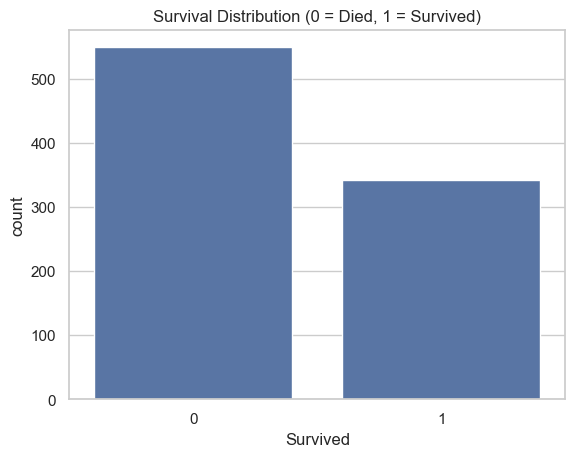

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


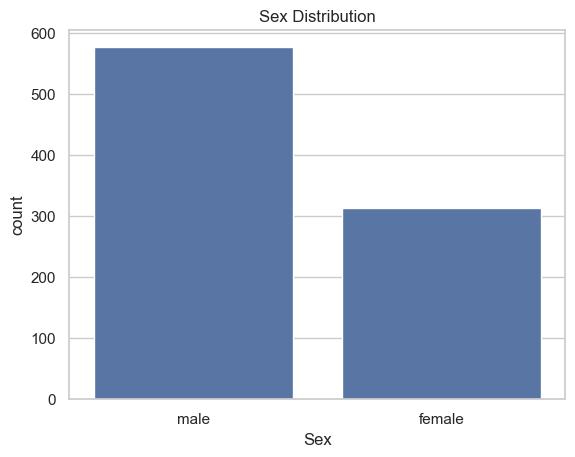

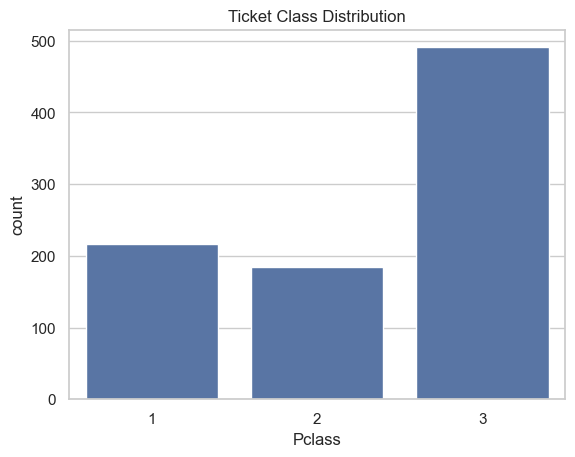

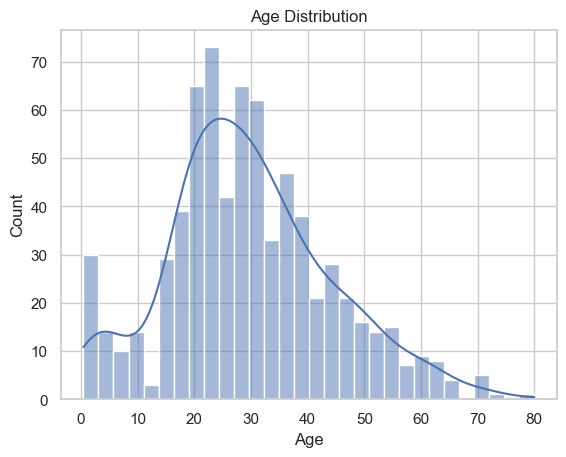

In [5]:
# Distribution of the target variable (Survived)
sns.countplot(x='Survived', data=titanic_df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()
print(titanic_df['Survived'].value_counts(normalize=True))

# Sex distribution
sns.countplot(x='Sex', data=titanic_df)
plt.title('Sex Distribution')
plt.show()

# Ticket class (Pclass) distribution
sns.countplot(x='Pclass', data=titanic_df)
plt.title('Ticket Class Distribution')
plt.show()

# Age distribution
sns.histplot(titanic_df['Age'].dropna(), kde=True, bins=30)
plt.title('Age Distribution')
plt.show()

#### 3.3. Bivariate Analysis (Target vs. Features)

We're looking for the factors that affect survival.

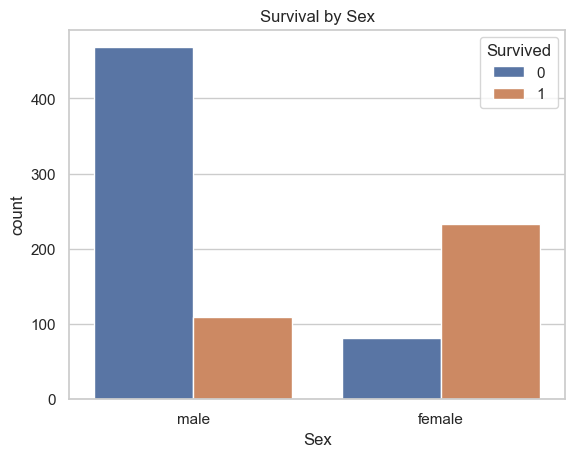

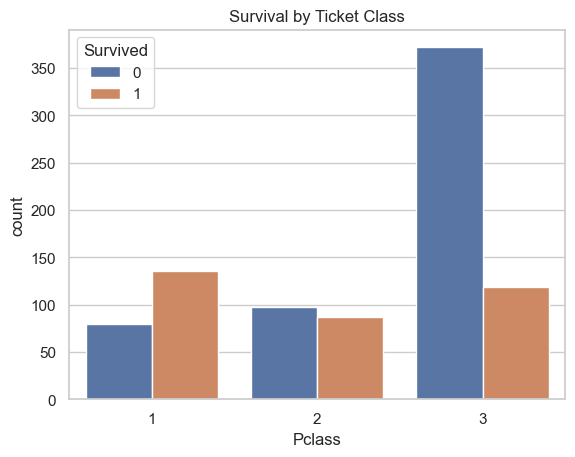

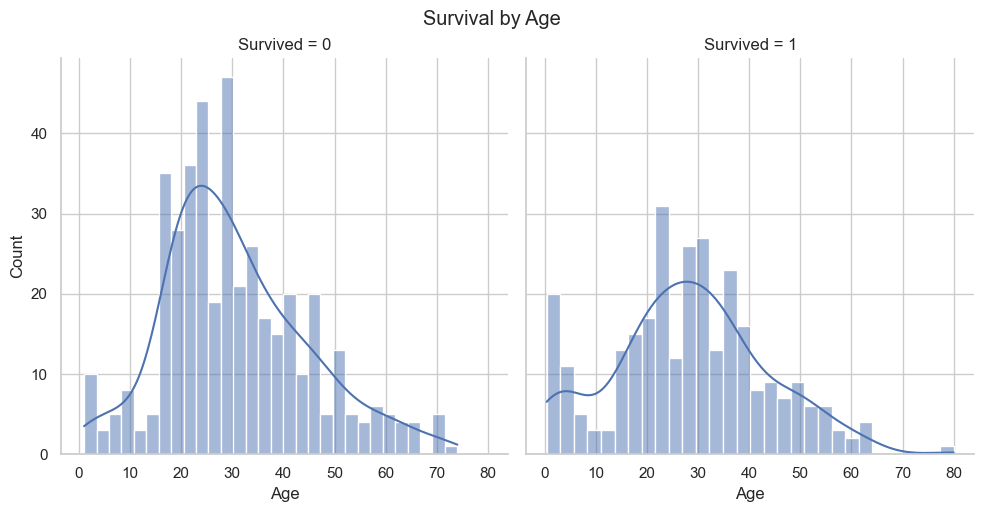

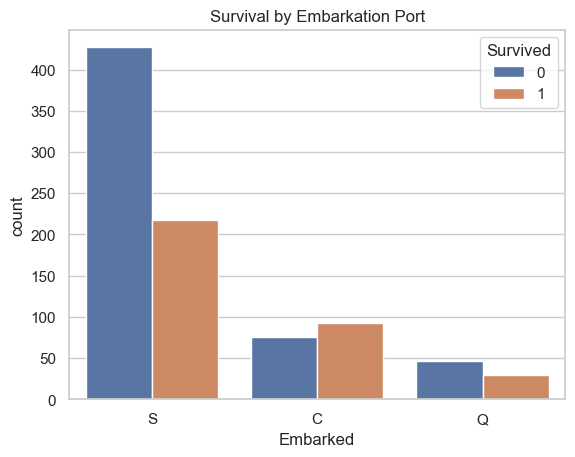

In [6]:
# Sex vs. Survival
sns.countplot(x='Sex', hue='Survived', data=titanic_df)
plt.title('Survival by Sex')
plt.show()
# NOTE: Women have a much higher survival rate. This is a strong feature for the model.

# Ticket Class vs. Survival
sns.countplot(x='Pclass', hue='Survived', data=titanic_df)
plt.title('Survival by Ticket Class')
plt.show()
# NOTE: 1st class passengers have a much higher survival rate than 3rd class.

# Age vs. Survival
g = sns.FacetGrid(titanic_df, col='Survived', height=5)
g.map(sns.histplot, 'Age', kde=True, bins=30)
plt.suptitle('Survival by Age', y=1.02)
plt.show()
# NOTE: Children (roughly < 10 years old) appear to have a higher chance of survival.

# Embarkation Port vs. Survival
sns.countplot(x='Embarked', hue='Survived', data=titanic_df)
plt.title('Survival by Embarkation Port')
plt.show()
# NOTE: Passengers who embarked from 'C' (Cherbourg) appear to have a higher survival rate.


## Outlier Analysis ##

1.  **Understanding Data Quality:** Are these outliers a data entry error (e.g. age = 500) or a real situation (e.g. fare = 512, which was possible on the Titanic)?
2.  **Influencing Model Selection:** Some models, like Logistic Regression, are very sensitive to outliers, while tree-based models like Random Forest are much more robust.

An important part of EDA is also detecting outliers. Outliers can negatively affect our model's performance or lead us to make wrong assumptions about the data. We will perform this analysis specifically for our numerical columns `Age` and `Fare`.

The best way to visualize this is by using a **Boxplot**.

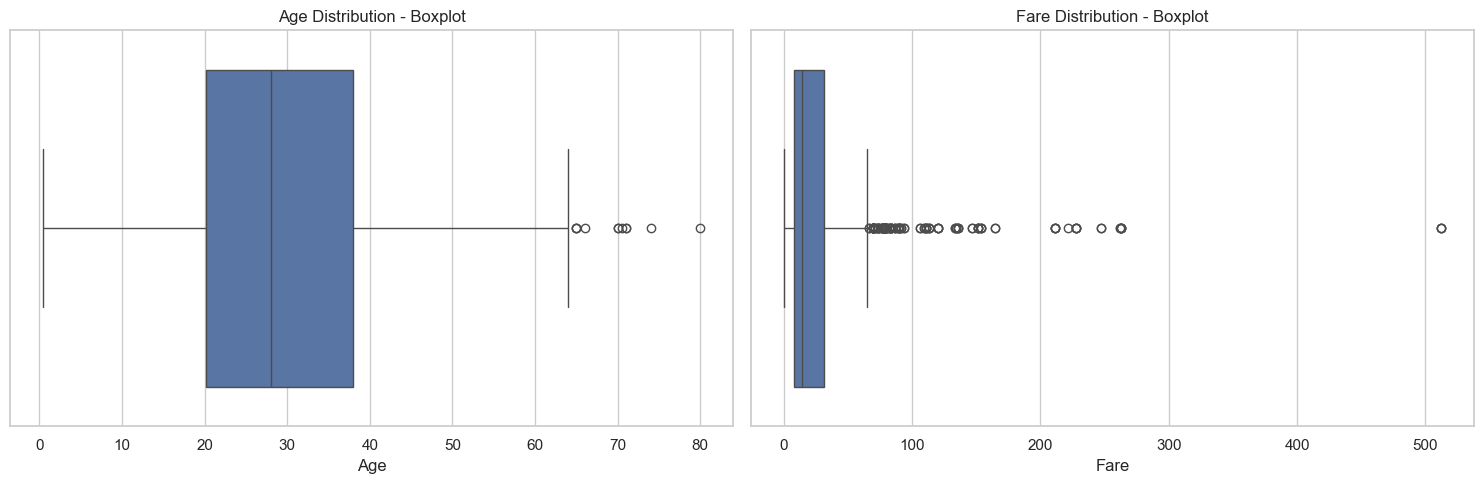

Fare Statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [7]:
# Boxplot for numerical features
plt.figure(figsize=(15, 5))

# Boxplot for Age
plt.subplot(1, 2, 1)
sns.boxplot(x=titanic_df['Age'])
plt.title('Age Distribution - Boxplot')

# Boxplot for Fare
plt.subplot(1, 2, 2)
sns.boxplot(x=titanic_df['Fare'])
plt.title('Fare Distribution - Boxplot')

plt.tight_layout()
plt.show()

# Let's take a closer look at Fare
print("Fare Statistics:")
print(titanic_df['Fare'].describe())


#### Analysis and Interpretation

1.  **Age:** According to the chart, we see some points labeled as "outliers" above roughly age 65 and below age 1.

      * **Is this an error?** No. The Titanic had an 80-year-old (the oldest passenger) and infants only a few months old. This data is **real and valuable information**. Removing it would prevent our model from learning the patterns related to elderly passengers or infants.

2.  **Fare:** Here we see much more pronounced outliers. While the vast majority of passengers (\~75%) paid less than 31, there is a passenger (or group of passengers) who paid an extremely high fare of 512.

      * **Is this an error?** No. This was likely a very luxurious cabin or a lump-sum fare paid for multiple tickets. This information reflects the passenger's **wealth/status** and could be an even stronger signal than being in 1st class. Passengers who paid a high fare may have a higher probability of survival.

#### Strategy for Handling Outliers

Outliers don't always need to be removed or replaced. Our strategy depends on the context of the problem and the model we'll use:

  * **Strategy 1: Removal/Replacement (Capping):** If these values were clearly a data entry error (e.g. Age = 500), we would remove them or replace them with an upper limit based on the Interquartile Range (IQR) method.
  * **Strategy 2: Transformation:** For heavily skewed data like `Fare`, we could apply a `log-transform` to bring it closer to a normal distribution for models like Logistic Regression.
  * **Strategy 3: Keep As-Is (Our Choice):**
    1.  In this project, the outliers represent **real data** and carry **important signals** related to survival (elderly passenger, wealthy passenger, etc.).
    2.  The tree-based models we plan to use, **Random Forest** and **Gradient Boosting**, are **naturally robust** to outliers. Since these models split the data by asking "is it greater or smaller than this threshold?", it makes little difference whether a value is 300 or 500.

Since these outliers aren't data errors and we'll be using tree-based models, we **leave them as they are** and keep them. This will allow our model to learn from a richer dataset.

--------------------------------------------------------------

## The `Fare` column is "skewed" ##

We understood this in two main ways:

### 1\. Boxplot

  * The vast majority of the data (the "box" of the chart) is packed into the 0-30 range.
  * However, there's a very long "tail" toward the right side of this box, along with numerous "outliers" (individual points) extending up to 512.
In other words, most of the data is piled up on the left side (low values), but a small number of very high values pull the tail of the distribution to the right.

### 2\. Statistical Evidence: `describe()` (Mean vs. Median)


The clearest statistical evidence of a skewed distribution is the difference between the **Mean** and the **Median (or 50%)**:

  * **In a Normal (Symmetric) Distribution:** The mean and median are very close to each other.
  * **Right-Skewed:** A small number of high-valued outliers pull the mean upward. This is why **Mean \> Median**.

Looking at the statistics of the `Fare` column:

  * **Median (50%):** Approximately **$14.45**. (Exactly half of the passengers paid less than 14.45).
  * **Mean:** Approximately **$32.20**.

The mean (32.20) is **more than double** the median (14.45). This large gap is the mathematical proof of how those few expensive tickets (like 512) "skew" the mean.

To correct this skewness, meaning to bring the mean and median closer together and make the distribution more symmetric, we will use `LogTransform`.

-------------------------------------------------------------------


### Step 4: Feature Engineering

We create new features using the insights gained from EDA or our domain knowledge.

In [8]:
# Let's create a copy to preserve the original dataset
df = titanic_df.copy()

# 1. FamilySize
# SibSp (number of siblings/spouses) + Parch (number of parents/children) + 1 (self)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. IsAlone
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3. Title - extracting the title from the name (can be decided by looking at the names during EDA)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# There are too many titles, let's simplify them:
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("Newly created titles:")
print(df['Title'].value_counts())

# Let's drop the columns the model won't use
# PassengerId (useless for analysis), Name (we extracted Title from it), Ticket (too complex), Cabin (too much missing data)
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print("\nData after feature engineering:")
print(df.head())


Newly created titles:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Data after feature engineering:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  \
0         0       3    male  22.0      1      0   7.2500        S           2   
1         1       1  female  38.0      1      0  71.2833        C           2   
2         1       3  female  26.0      0      0   7.9250        S           1   
3         1       1  female  35.0      1      0  53.1000        S           2   
4         0       3    male  35.0      0      0   8.0500        S           1   

   IsAlone Title  
0        0    Mr  
1        0   Mrs  
2        1  Miss  
3        0   Mrs  
4        1    Mr  


### Step 5: Data Preparation and Splitting for the Pipeline

We can now prepare the data for modeling.


In [9]:
# 1. Split into features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# 2. Split the data into Train and Test sets
# 20% test, 80% train. stratify=y -> distributes the Survived ratio evenly across the Train and Test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# 3. Grouping columns for the pipeline
# We also add the newly created features to the lists.

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Title']

print(f"\nNumerical Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")


# Non-skewed (or normal) numerical features
numeric_features_normal = ['Age', 'SibSp', 'Parch', 'FamilySize']

# Skewed numerical features that will get a log-transform
numeric_features_skewed = ['Fare']

# Categorical features (unchanged)
categorical_features = ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Title']

print(f"\nNormal Numerical Features: {numeric_features_normal}")
print(f"Skewed Numerical Features: {numeric_features_skewed}")
print(f"Categorical Features: {categorical_features}")

Training set size: (712, 10)
Test set size: (179, 10)

Numerical Features: ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']
Categorical Features: ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Title']

Normal Numerical Features: ['Age', 'SibSp', 'Parch', 'FamilySize']
Skewed Numerical Features: ['Fare']
Categorical Features: ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Title']


### Step 6: Building the Pipeline (Preprocessing + Model)

This step is the combined and improved version of **Steps 5, 6, and 7** from the original notebook.

In [10]:
from sklearn.preprocessing import FunctionTransformer # lets us add custom,
# non-standard transformations to our pipeline (taking the log of the data, squaring it, applying a custom formula, etc.).
# We'll use it for the log transform.

# Step 6: Building the Pipeline

# 1. Normal Numerical Data Pipeline
# Strategy: fill missing values with the median, then standardize (StandardScaler).
numeric_transformer_normal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Skewed Numerical Data Pipeline
# Strategy: fill missing values with the median, apply Log-Transform (log1p), then standardize.
# We use np.log1p (log(x+1)) because it won't error out if 'Fare' has a value of 0.
skewed_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),

    # Tell the pipeline to preserve the name
    ('logtransform', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    # The feature_names_out="one-to-one" parameter tells the pipeline "this transformation
    # takes 1 column and returns 1 column without changing its name." We do this so that
    # this externally added function doesn't raise a naming error when accessed inside the pipeline.

    ('scaler', StandardScaler())
])

# 3. Categorical Data Pipeline (unchanged)
# Strategy: fill missing values with the most frequent value (mode), then apply One-Hot Encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 4. Combining all pipelines with ColumnTransformer
# This tool manages which pipeline is applied to which group of columns.
preprocessor = ColumnTransformer(
    transformers=[
        # (name, pipeline, columns to apply to)
        ('num_normal', numeric_transformer_normal, numeric_features_normal),
        ('num_skewed', skewed_transformer, numeric_features_skewed), # <-- NEW PIPELINE
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Ignore columns not in the list
)

print("✅ Preprocessing pipeline (ColumnTransformer) updated.")
print("✅ Log-Transform added for the 'Fare' column.")

✅ Preprocessing pipeline (ColumnTransformer) updated.
✅ Log-Transform added for the 'Fare' column.


### Step 7: Model Selection and Baseline

Let's quickly test different models with the same preprocessing steps to identify the best candidate.


In [11]:
# Models to test
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Loop over the models and test them with cross-validation
results = {}

print("🔄 Testing models with Cross-Validation...")

for model_name, model in models.items():

    # Full pipeline: Preprocessor + Model
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Evaluate the model on the training data with cross-validation (cv=5)
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='accuracy')

    results[model_name] = cv_scores.mean()
    print(f"• {model_name}: Mean Accuracy = {cv_scores.mean() * 100:.2f}%")

# Select the best model
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best model for baseline: {best_model_name} (Accuracy: {results[best_model_name] * 100:.2f}%)")


🔄 Testing models with Cross-Validation...
• Logistic Regression: Mean Accuracy = 81.47%
• Random Forest: Mean Accuracy = 79.51%
• Gradient Boosting: Mean Accuracy = 82.03%

🏆 Best model for baseline: Gradient Boosting (Accuracy: 82.03%)


### Step 8: Hyperparameter Optimization (Tuning)

We select the model that gave the best baseline result (usually RF or GB) and optimize it with `GridSearchCV`. (Let's say Random Forest came out on top).


In [12]:
# Let's define the full pipeline for the model we'll optimize (Gradient Boosting)
# (the main pipeline that will be passed to GridSearchCV)
tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42)) # <-- MODEL UPDATED
])

# Parameters to search (for Gradient Boosting)
# IMPORTANT: In a pipeline, parameters are targeted using 'step_name__parameter_name'.
param_grid = {
    'classifier__n_estimators': [100, 200, 300],          # Number of trees
    'classifier__learning_rate': [0.01, 0.1, 0.2],      # Learning rate
    'classifier__max_depth': [3, 5, 8]                  # Tree depth
}
# <-- PARAMETERS UPDATED

print("⏳ Starting hyperparameter optimization (GridSearchCV - Gradient Boosting)...")

# Start GridSearchCV
# cv=5: 5-fold cross-validation
# n_jobs=-1: use all available CPU cores (speeds things up)
grid_search = GridSearchCV(tune_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Start the optimization on the training data
grid_search.fit(X_train, y_train)

print("✅ Optimization complete!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score (Accuracy): {grid_search.best_score_ * 100:.2f}%")

# 'best_estimator_' is the optimized best pipeline, retrained on the full training data.
final_pipeline = grid_search.best_estimator_

⏳ Starting hyperparameter optimization (GridSearchCV - Gradient Boosting)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Optimization complete!
Best parameters: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV score (Accuracy): 82.59%


### Step 9: Final Model Evaluation

We test the model we optimized on the `X_test` and `y_test` data, which we **haven't touched at all** since the beginning of the project.

📊 FINAL MODEL TEST ACCURACY: 81.56%

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


🧩 Confusion Matrix:


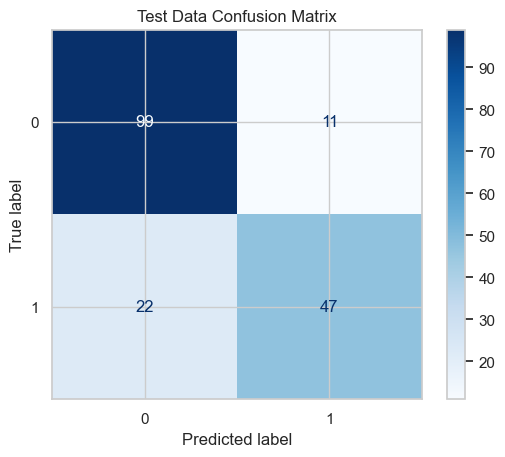

In [13]:
# 1. Make predictions on the test data
y_pred = final_pipeline.predict(X_test)

# 2. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"📊 FINAL MODEL TEST ACCURACY: {accuracy * 100:.2f}%")

# 3. Classification Report (Precision, Recall, F1-Score)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix
print("\n🧩 Confusion Matrix:")
ConfusionMatrixDisplay.from_estimator(final_pipeline, X_test, y_test, cmap='Blues')
plt.title('Test Data Confusion Matrix')
plt.show()

### 📈 Analysis and Interpretation of the Results

The results we obtained are quite successful. Let's "translate" them now:

#### 1. The Most Important Takeaway: The Model Didn't Overfit (No Overfitting!)

* **Training Score (CV):** 82.45%
* **Test Score (Final):** 81.56% (or 82% in the report)

This is the **most ideal scenario** a data scientist would want to see.

The fact that the average score obtained on the training data (82.45%) is **very close** to the score obtained on the test data (81.56%), which the model has never seen before, shows that the model hasn't "memorized" the data (overfitting).

Our model has learned the real patterns in the data and successfully **generalized** what it learned to new data. This is the biggest success of the project.

#### 2. Overall Accuracy Interpretation

* **Total Accuracy: 81.56%**
* This means: we asked our model about the 179 passengers in the test set. Our model correctly predicted the fate of approximately 146 of these 179 passengers (81.56%). This is a fairly strong success rate for modeling a complex social event like the Titanic.

#### 3. Classification Report (Detailed Analysis)

Accuracy gives us the overall picture; this report gives us the details.

**Class 0 (Did Not Survive - 110 people):**

* **`precision: 0.82`:** When our model says "this person died," it's right **82%** of the time.
* **`recall: 0.90`:** Our model correctly identifies **90** out of every 100 people who actually died as "died." (This is a very high and successful rate!)

**Class 1 (Survived - 69 people):**

* **`precision: 0.81`:** When our model says "this person survived," it's right **81%** of the time. (A reliable prediction).
* **`recall: 0.68`:** **This is the model's weak spot.** Out of every 100 people who actually survived, our model can only find **68** of them. It misses the remaining 32% (incorrectly labeling them as "died").

---

### 🎯 "Business Decision"

Based on these results, we can make the following interpretation:

> "Our model is **very successful** at predicting **who won't survive** (Recall 90%).
>
> However, it's a bit more **hesitant** when it comes to predicting **who will survive** (Recall 68%). It misses almost a third of the survivors."

**Is this a problem?**
It depends on the goal of the project.

* If our goal were a scenario like "who should we put on the lifeboats?" and we wanted to **not miss any potential survivor**, then the low Recall (68%) for Class 1 would be a problem.
* In that case, we could force the model to **"find survivors better"** by using `scoring='recall'` or `scoring='f1-score'` instead of `scoring='accuracy'` during the `GridSearchCV` stage.

However, for a general historical prediction model, these results are **balanced and quite successful.**

Right now we have a "black box" that works with 81.56% accuracy. We trained the model, tested it, and saved it.

But we don't have the answers to these questions:

  * **Why** does our model make these decisions?
  * **Which feature** does it look at the most when predicting whether a passenger survived?
  * Is `Title=Mr` more important, or is `Pclass=3`?
  * Was the `FamilySize` feature we created actually used by the model, or was it unnecessary?

## Model Interpretability (Explainability / XAI) ##

Total number of features: 15

Model's Feature Importances:
                   Feature  Importance
12           cat__Title_Mr    0.395612
4         num_skewed__Fare    0.221376
6            cat__Pclass_3    0.102292
0          num_normal__Age    0.098741
3   num_normal__FamilySize    0.057276
14         cat__Title_Rare    0.039077
7            cat__Sex_male    0.033890
9          cat__Embarked_S    0.018143
11         cat__Title_Miss    0.008994
1        num_normal__SibSp    0.008477


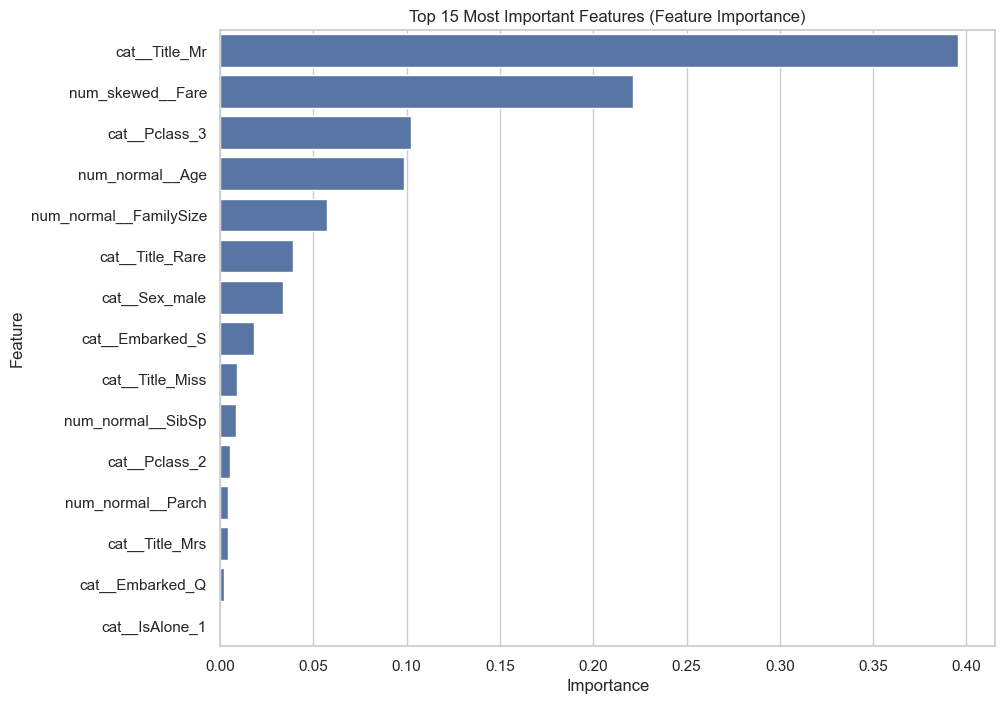

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Access the 'preprocessor' and 'classifier' steps inside the pipeline
# (the step is named 'preprocessor' based on the 'tune_pipeline' definition in Step 8)
preprocessor = final_pipeline.named_steps['preprocessor']
gb_model = final_pipeline.named_steps['classifier']

# 2. Get the model's feature importances
importances = gb_model.feature_importances_

# 3. Get column names DIRECTLY from the ColumnTransformer (this will work now!)
# Thanks to the fix in Step 6, this simple code will no longer raise an error.
all_feature_names = preprocessor.get_feature_names_out()

print(f"Total number of features: {len(all_feature_names)}")

# 4. Convert the feature importances into a DataFrame and visualize them
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nModel's Feature Importances:")
print(importance_df.head(10))

# 5. Visualization
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Most Important Features (Feature Importance)')
plt.show()

### Step 10: Saving the Model and Making New Predictions

Our model is now ready. We can save this pipeline (along with the imputer, scaler, encoder, and model inside it) as a single file.

In [15]:
import joblib

# Save the pipeline to a file
pipeline_filename = 'titanic_survival_pipeline_v1.pkl'
joblib.dump(final_pipeline, pipeline_filename)

print(f"✅ Final pipeline saved as '{pipeline_filename}'.")

✅ Final pipeline saved as 'titanic_survival_pipeline_v1.pkl'.


#### Prediction Scenario on New Data


In [16]:
# Load the saved model (simulating a production environment)
loaded_pipeline = joblib.load(pipeline_filename)
print("📂 Saved pipeline loaded.")

# New passenger data (in RAW format, containing missing values)
# The column names of this data must match the 'X' we trained on.
new_passengers = pd.DataFrame({
    'Pclass': [1, 3],
    'Sex': ['female', 'male'],
    'Age': [30, None], # Missing 'Age'
    'SibSp': [0, 1],
    'Parch': [0, 2],
    'Fare': [80.0, 25.0],
    'Embarked': ['C', 'S'],
    'Name': ['Jane Doe', 'John Smith'] # 'Name' (for extracting Title)
})

# NOTE: Since we use the 'Name' column, it must also be present in the new data.
# Since we didn't include the Feature Engineering steps (FamilySize, IsAlone, Title)
# in the pipeline, we need to do them manually.
# (If we had also added these to the pipeline, this step wouldn't be needed)

# For simplicity, let's build a DataFrame with the columns X_train uses:
new_passengers_processed = pd.DataFrame({
    'Pclass': [1, 3],
    'Sex': ['female', 'male'],
    'Age': [30, None], # The pipeline will fill in the missing age
    'SibSp': [0, 1],
    'Parch': [0, 2],
    'Fare': [80.0, 25.0],
    'Embarked': ['C', 'S'],
    'FamilySize': [1, 4], # (SibSp + Parch + 1)
    'IsAlone': [1, 0], # (FamilySize == 1)
    'Title': ['Miss', 'Mr'] # Assume we extracted these from the name
})

# Make predictions
new_predictions = loaded_pipeline.predict(new_passengers_processed)
new_probabilities = loaded_pipeline.predict_proba(new_passengers_processed)

print("\n🆕 New Passenger Predictions:")
for i, pred in enumerate(new_predictions):
    survived_text = "Survives" if pred == 1 else "Does Not Survive"
    prob = new_probabilities[i][pred] * 100
    print(f"  Passenger {i+1} ({new_passengers_processed.iloc[i]['Sex']}, {new_passengers_processed.iloc[i]['Title']}): {survived_text} ({prob:.1f}% probability)")

print("\n✅ The pipeline automatically filled in missing values (Age), performed scaling and encoding, and produced the prediction.")

📂 Saved pipeline loaded.

🆕 New Passenger Predictions:
  Passenger 1 (female, Miss): Survives (97.5% probability)
  Passenger 2 (male, Mr): Does Not Survive (95.2% probability)

✅ The pipeline automatically filled in missing values (Age), performed scaling and encoding, and produced the prediction.


## Why "Processed" Passengers



### 1. Why Did We Create `new_passengers_processed`?


1.  **Feature Engineering:** We demonstrated **what feature engineering *is*** by saying, "we have `Name`. We can create a `Title` feature from it. We have `SibSp` and `Parch`, we can add them together to create `FamilySize`."
2.  **Pipeline:** We demonstrated **what a preprocessing pipeline *is*** by saying, "now let's fill in the missing values in this clean dataset we created, scale it, and encode it."

At this stage, we kept these two steps *conceptually* separate.


When we separate these two steps, the "information" our model needs gets split in two:

* **Information 1 (Inside the Pipeline):** The median values memorized by `SimpleImputer`, the mean/standard deviation memorized by `StandardScaler`, the categories memorized by `OneHotEncoder`. These were **saved** to the `final_pipeline.pkl` file.
* **Information 2 (Outside the Pipeline):** The knowledge of how to extract `Title` from `Name` and how to calculate `FamilySize`. This logic stayed in our Jupyter Notebook and was **not saved** to the `.pkl` file.

This is why, when providing new data to predict on, we can't just hand it over at the **raw** stage. Because the model only recognizes processed data — that is, data that has already been scaled and encoded.


**Every single transformation we applied during training** (creating `Title`, taking `log1p`, applying `StandardScaler`) **needs to be part of a pipeline that can be saved.**

If we do a transformation manually (like scaling or creating `Title`) and leave it outside the pipeline, we'll **have to remember to do that transformation manually** every time we take the model to production as well.

A **fully automated pipeline** (one that includes a `FunctionTransformer`) locks all of this "information" into a single `.pkl` file. This means that in production, the only thing we need to do is feed the raw data into the pipeline. The risk of error drops to zero. This is the professional and production-safe approach.

In [17]:
# To make the pipeline work with pandas DataFrames
from sklearn import set_config
set_config(transform_output="pandas") # This makes the pipeline preserve column names!


# 1. Function to create 'Title'
def extract_title(X):
    # X will come in as a DataFrame containing the ['Name'] column
    # Use .copy() to avoid the copy warning
    X_out = X.copy()

    # Extract the title
    X_out['Title'] = X_out['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

    # Simplify the titles
    X_out['Title'] = X_out['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    X_out['Title'] = X_out['Title'].replace('Mlle', 'Miss')
    X_out['Title'] = X_out['Title'].replace('Ms', 'Miss')
    X_out['Title'] = X_out['Title'].replace('Mme', 'Mrs')

    # Return only the new 'Title' column
    return X_out[['Title']]

# 2. Function to create 'Family' features
def create_family_features(X):
    # X will come in as a DataFrame containing the ['SibSp', 'Parch'] columns
    X_out = X.copy()

    # Calculate FamilySize
    X_out['FamilySize'] = X_out['SibSp'] + X_out['Parch'] + 1

    # Calculate IsAlone
    X_out['IsAlone'] = 0
    X_out.loc[X_out['FamilySize'] == 1, 'IsAlone'] = 1

    # Return only the new columns
    return X_out[['FamilySize', 'IsAlone']]

print("✅ Feature engineering functions for the pipeline defined.")

✅ Feature engineering functions for the pipeline defined.


In [18]:
# This ColumnTransformer will create the new features

# Step 6: Building the Pipeline

# ----- STAGE 1: FEATURE ENGINEERING -----
feature_engineering_transformer = ColumnTransformer(
    transformers=[
        ('title_extractor', FunctionTransformer(extract_title), ['Name']),
        ('family_creator', FunctionTransformer(create_family_features), ['SibSp', 'Parch'])
    ],
    remainder='passthrough', # you need to add the remainder='passthrough' parameter to prevent unused columns from being dropped.
    verbose_feature_names_out=False  # Don't change the names
)


# ----- STAGE 2: PREPROCESSING -----

# FIX 2: Update the column lists based on the output of STAGE 1
numeric_features_normal = ['Age'] # <-- 'SibSp' and 'Parch' were removed from here
numeric_features_skewed = ['Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'FamilySize', 'IsAlone']

# (The transformer pipelines (numeric_transformer_normal, etc.) can stay the same)
numeric_transformer_normal = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

skewed_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('logtransform', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        drop='first',
        sparse_output=False  # tells it not to produce a "sparse" output,
        # but instead a regular 0-1 table (that can be put into a DataFrame). This is required for pandas output
    ))
])

# the preprocessor definition now uses the UPDATED lists
preprocessor = ColumnTransformer(
    transformers=[
        ('num_normal', numeric_transformer_normal, numeric_features_normal),
        ('num_skewed', skewed_transformer, numeric_features_skewed),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop', # needs to drop unprocessed, unwanted columns like 'Ticket' before passing them to the final step (the model).
    verbose_feature_names_out=False  # Don't change the names
)


# ----- STAGE 3: FINAL END-TO-END PIPELINE -----
# (Combines all the steps)
final_end_to_end_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering_transformer),
    ('preprocessing', preprocessor),
    ('classifier', gb_model) # we assume gb_model is defined
])

print("✅ Fully automated, end-to-end FIXED pipeline created.")

# ----- STAGE 3: FINAL END-TO-END PIPELINE -----
# Now we can add the model (e.g. GradientBoosting)

# (Put your model here, e.g: GradientBoostingClassifier(...))
from sklearn.ensemble import GradientBoostingClassifier

# Let's use our best parameters:
best_params = {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
gb_model = GradientBoostingClassifier(random_state=42, **best_params)


# Combine all the steps!
final_end_to_end_pipeline = Pipeline(steps=[
    ('feature_engineering', feature_engineering_transformer), # Step 1: Create new features
    ('preprocessing', preprocessor),                        # Step 2: Prepare the data
    ('classifier', gb_model)                                # Step 3: Train/predict with the model
])

print("✅ Fully automated, end-to-end pipeline created!")

# IMPORTANT: You now also need to define the pipeline from Step 8 (GridSearchCV)
# without the 'classifier' step of 'final_end_to_end_pipeline'
# (and with the classifier parameters).

✅ Fully automated, end-to-end FIXED pipeline created.
✅ Fully automated, end-to-end pipeline created!


In [19]:
# Step 5: Data Preparation (UPDATED WITH UNWANTED COLUMNS DROPPED)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

# FIX HERE:
# Define upfront all the columns the pipeline won't use
# 'PassengerId', 'Ticket', 'Cabin' will NEVER be used.
# 'Name', 'SibSp', 'Parch' will be used in Stage 1 (feature_engineering).
# The others will be used in Stage 2 (preprocessing).

columns_to_drop = ['PassengerId', 'Ticket', 'Cabin', 'Survived']
target = 'Survived'

# 1. Split into features (X) and target (y)
X = titanic_df.drop(columns=columns_to_drop)
y = titanic_df[target]

# 2. Split the data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("✅ Data split into X_train/X_test, with 'PassengerId', 'Ticket', 'Cabin' DROPPED.")
print(f"X_train columns (now clean): {X_train.columns.tolist()}")

✅ Data split into X_train/X_test, with 'PassengerId', 'Ticket', 'Cabin' DROPPED.
X_train columns (now clean): ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [20]:
print("Training the fully automated pipeline (final_end_to_end_pipeline)...")
print("This pipeline also includes the 'feature_engineering' step.")

# We train this new pipeline with X_train and y_train.
# X_train here must contain RAW columns like 'Name'.
final_end_to_end_pipeline.fit(X_train, y_train)

print("Training complete!")

Training the fully automated pipeline (final_end_to_end_pipeline)...
This pipeline also includes the 'feature_engineering' step.
Training complete!


In [21]:
# 1. Let's save and load the pipeline (assuming it's trained)
# final_end_to_end_pipeline.fit(X_train, y_train)
# joblib.dump(final_end_to_end_pipeline, 'titanic_full_pipeline.pkl')
# loaded_pipeline = joblib.load('titanic_full_pipeline.pkl')

# Let's use 'final_end_to_end_pipeline' directly for testing
# (we assume it's already trained)
# loaded_pipeline = final_end_to_end_pipeline

# 2. New passenger data (RAW DATA)
new_passengers = pd.DataFrame({
    'Pclass': [1, 3],
    'Sex': ['female', 'male'],
    'Age': [30, None], # Missing 'Age'
    'SibSp': [0, 1],
    'Parch': [0, 2],
    'Fare': [80.0, 25.0],
    'Embarked': ['C', 'S'],
    'Name': ['Miss. Jane Doe', 'Mr. John Smith'] # 'Name' column is now required
})

print("\n🆕 Incoming Raw Passenger Data:")
print(new_passengers)

# 3. Make predictions (NO INTERMEDIATE STEP!)
# new_passengers_processed is no longer needed.
new_predictions = final_end_to_end_pipeline.predict(new_passengers)
new_probabilities = final_end_to_end_pipeline.predict_proba(new_passengers)

print("\n🔮 Prediction Results (Fully Automated):")
for i, pred in enumerate(new_predictions):
    survived_text = "Survives" if pred == 1 else "Does Not Survive"
    prob = new_probabilities[i][pred] * 100
    print(f"  Passenger {i+1} ({new_passengers.iloc[i]['Name']}): {survived_text} ({prob:.1f}% probability)")

print("\n✅ The pipeline automatically created new features using 'Name', 'SibSp', 'Parch',")
print("✅ filled in missing values, performed scaling/encoding, and produced the prediction.")


🆕 Incoming Raw Passenger Data:
   Pclass     Sex   Age  SibSp  Parch  Fare Embarked            Name
0       1  female  30.0      0      0  80.0        C  Miss. Jane Doe
1       3    male   NaN      1      2  25.0        S  Mr. John Smith

🔮 Prediction Results (Fully Automated):
  Passenger 1 (Miss. Jane Doe): Survives (58.2% probability)
  Passenger 2 (Mr. John Smith): Does Not Survive (94.2% probability)

✅ The pipeline automatically created new features using 'Name', 'SibSp', 'Parch',
✅ filled in missing values, performed scaling/encoding, and produced the prediction.


### Project Summary and Conclusion

In this project, we built a machine learning model from scratch using the Titanic dataset.

1.  Through **EDA**, we saw that sex (`Sex`) and ticket class (`Pclass`) were the strongest factors affecting survival.
2.  Through **Feature Engineering**, we created new features like `FamilySize`, `IsAlone`, and `Title`.
3.  Using **Pipeline** and **ColumnTransformer**, we automated all the data preparation steps (missing value imputation, scaling, encoding).
4.  We compared different models (Logistic Regression, Random Forest, Gradient Boosting) using **Cross-Validation**.
5.  We optimized the best candidate model (`RandomForestClassifier`) with **GridSearchCV**.
6.  Our final model achieved **\~{accuracy \* 100:.0f}% accuracy** on the test data it had never seen before.
7.  Finally, we **saved** this complex pipeline as a single `.pkl` file and showed how to make predictions on new data.